In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime

In [11]:
def process_jakob_streamflow(excel_file, output_folder, plot=True):
    """
    Process Jakob's Indus streamflow Excel file with multiple sheets and convert to CSV format.
    
    Parameters:
    excel_file (str): Path to the Excel file
    output_folder (str): Path to folder where CSV files will be saved
    plot (bool): Whether to create time series plots for each gauge
    
    Returns:
    dict: Dictionary with gauge_ids as keys and processed DataFrames as values
    """
    
    # Station name to ID mapping
    station_mapping = {
        'Mangla': '0112',
        'Marala': '0130',
        'Tarbela': '0128',
        'Daniyor': '0102',
        'Nowshera': '0129'
    }
    
    # Sheets to process
    sheet_names = ['Daniyor', 'Tarbela', 'Nowshera', 'Marala', 'Mangla']
    
    # Sheets that have D/M/YYYY date format (instead of M/D/YYYY)
    dayfirst_sheets = ['Tarbela']
    
    print(f"Processing Jakob's Indus streamflow file: {os.path.basename(excel_file)}")
    print(f"Station mapping: {station_mapping}")
    print(f"Sheets to process: {sheet_names}")
    print(f"Sheets with dayfirst date format: {dayfirst_sheets}")
    
    # Create output directory if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)
    
    results = {}
    successful = 0
    failed = 0
    
    # Process each sheet
    for sheet_name in sheet_names:
        print(f"\n{'='*60}")
        print(f"Processing sheet: {sheet_name}")
        print(f"{'='*60}")
        
        try:
            # Determine if this sheet needs dayfirst parsing
            use_dayfirst = sheet_name in dayfirst_sheets
            
            if use_dayfirst:
                # Read as strings to prevent Excel auto-parsing, then parse with dayfirst=True
                df = pd.read_excel(excel_file, sheet_name=sheet_name, dtype=str)
                print(f"   ⚠️ Using dayfirst=True for date parsing (D/M/YYYY format)")
            else:
                df = pd.read_excel(excel_file, sheet_name=sheet_name)
            
            print(f"Shape: {df.shape}")
            print(f"Columns: {list(df.columns)}")
            print(f"First few rows:")
            print(df.head())
            
            # Get gauge_id from mapping
            gauge_id = station_mapping.get(sheet_name, None)
            if gauge_id is None:
                print(f"   ⚠️ Warning: No mapping found for sheet '{sheet_name}'. Skipping...")
                failed += 1
                continue
            
            print(f"   Mapped '{sheet_name}' to ID: {gauge_id}")
            
            # Rename columns to standardized names
            df.columns = ['date', 'Q_obs']
            
            # Convert date column to datetime
            if use_dayfirst:
                df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
            else:
                df['date'] = pd.to_datetime(df['date'], errors='coerce')
            
            # Remove rows where date conversion failed
            n_before = len(df)
            df = df.dropna(subset=['date'])
            n_removed = n_before - len(df)
            if n_removed > 0:
                print(f"   ⚠️ Removed {n_removed} rows with unparseable dates")
            
            # Convert Q_obs to numeric, replacing non-numeric with NaN
            df['Q_obs'] = pd.to_numeric(df['Q_obs'], errors='coerce')
            
            # Replace 0 values with NaN (as specified: empty cells or 0 means no data)
            df.loc[df['Q_obs'] == 0, 'Q_obs'] = np.nan
            
            # Check for and remove duplicate dates
            n_duplicates = df.duplicated(subset=['date']).sum()
            if n_duplicates > 0:
                print(f"   ⚠️ Found {n_duplicates} duplicate dates - keeping first occurrence")
                df = df.drop_duplicates(subset=['date'], keep='first')
            
            # Sort by date
            df = df.sort_values('date').reset_index(drop=True)
            
            # Create complete date range and fill missing values
            if len(df) > 0:
                date_range = pd.date_range(start=df['date'].min(), 
                                         end=df['date'].max(), 
                                         freq='D')
                
                # Reindex to include all dates, keeping NaN for missing values
                df_complete = df.set_index('date').reindex(date_range).reset_index()
                df_complete.columns = ['date', 'Q_obs']
            else:
                df_complete = df
            
            # Sanity check: verify first year has reasonable monthly distribution
            first_year = df_complete['date'].dt.year.min()
            fy_data = df_complete[df_complete['date'].dt.year == first_year]
            month_counts = fy_data.groupby(fy_data['date'].dt.month)['Q_obs'].count()
            print(f"   📅 Sanity check ({first_year}) - days per month with data: "
                  f"{dict(month_counts)}")
            
            # Save to CSV using the 4-digit station ID
            output_file = os.path.join(output_folder, f"streamflow_{gauge_id}.csv")
            df_complete.to_csv(output_file, index=False)
            
            print(f"✅ Saved: {output_file}")
            print(f"   Date range: {df_complete['date'].min()} to {df_complete['date'].max()}")
            print(f"   Total records: {len(df_complete)}")
            print(f"   Valid data: {len(df_complete.dropna(subset=['Q_obs']))}")
            print(f"   Missing data: {len(df_complete) - len(df_complete.dropna(subset=['Q_obs']))}")
            
            # Create plot if requested
            if plot and len(df_complete) > 0:
                plt.figure(figsize=(14, 6))
                
                # Only plot non-NaN values for better visualization
                plot_data = df_complete.dropna(subset=['Q_obs']).copy()
                
                if len(plot_data) > 0:
                    plt.plot(plot_data['date'], plot_data['Q_obs'], 'b-', linewidth=0.8)
                    plt.title(f'Streamflow Time Series - {sheet_name} (ID: {gauge_id})', 
                             fontsize=14, fontweight='bold')
                    plt.xlabel('Date', fontsize=12)
                    plt.ylabel('Discharge (m³/s)', fontsize=12)
                    plt.grid(True, alpha=0.3)
                    plt.xticks(rotation=45)
                    plt.tight_layout()
                    
                    # Save plot using the 4-digit station ID
                    plot_file = os.path.join(output_folder, f"streamflow_{gauge_id}_plot.png")
                    plt.savefig(plot_file, dpi=300, bbox_inches='tight')
                    plt.show()
                    
                    print(f"   📊 Plot saved: {plot_file}")
                else:
                    print(f"   ⚠️ No valid data to plot for {sheet_name}")
            
            # Store in results using the 4-digit station ID
            results[gauge_id] = df_complete
            successful += 1
            
        except Exception as e:
            print(f"❌ Error processing sheet {sheet_name}: {str(e)}")
            import traceback
            traceback.print_exc()
            failed += 1
    
    print(f"\n{'='*60}")
    print(f"Processing complete!")
    print(f"Successfully processed: {successful} sheets")
    print(f"Failed: {failed} sheets")
    print(f"Total stations processed: {len(results)}")
    
    return results

## Process Jakob's Indus Streamflow Data

Execute the processing function to read all sheets from the Excel file and save as individual CSV files.

Processing Jakob's Indus streamflow file: IndusDataforJustine.xlsx
Station mapping: {'Mangla': '0112', 'Marala': '0130', 'Tarbela': '0128', 'Daniyor': '0102', 'Nowshera': '0129'}
Sheets to process: ['Daniyor', 'Tarbela', 'Nowshera', 'Marala', 'Mangla']
Sheets with dayfirst date format: ['Tarbela']

Processing sheet: Daniyor
Shape: (13515, 2)
Columns: ['Date', 'Q [m3/s]']
First few rows:
        Date  Q [m3/s]
0 1980-01-01     59.43
1 1980-01-02     58.90
2 1980-01-03     58.60
3 1980-01-04     58.00
4 1980-01-05     57.70
   Mapped 'Daniyor' to ID: 0102
   📅 Sanity check (1980) - days per month with data: {1: np.int64(31), 2: np.int64(29), 3: np.int64(31), 4: np.int64(30), 5: np.int64(31), 6: np.int64(30), 7: np.int64(31), 8: np.int64(31), 9: np.int64(30), 10: np.int64(31), 11: np.int64(30), 12: np.int64(31)}
✅ Saved: /home/jberg/OneDrive/Data_collection_Himalaya/streamflow/Pakistan/processed_jakob/streamflow_0102.csv
   Date range: 1980-01-01 00:00:00 to 2016-12-31 00:00:00
   Total r

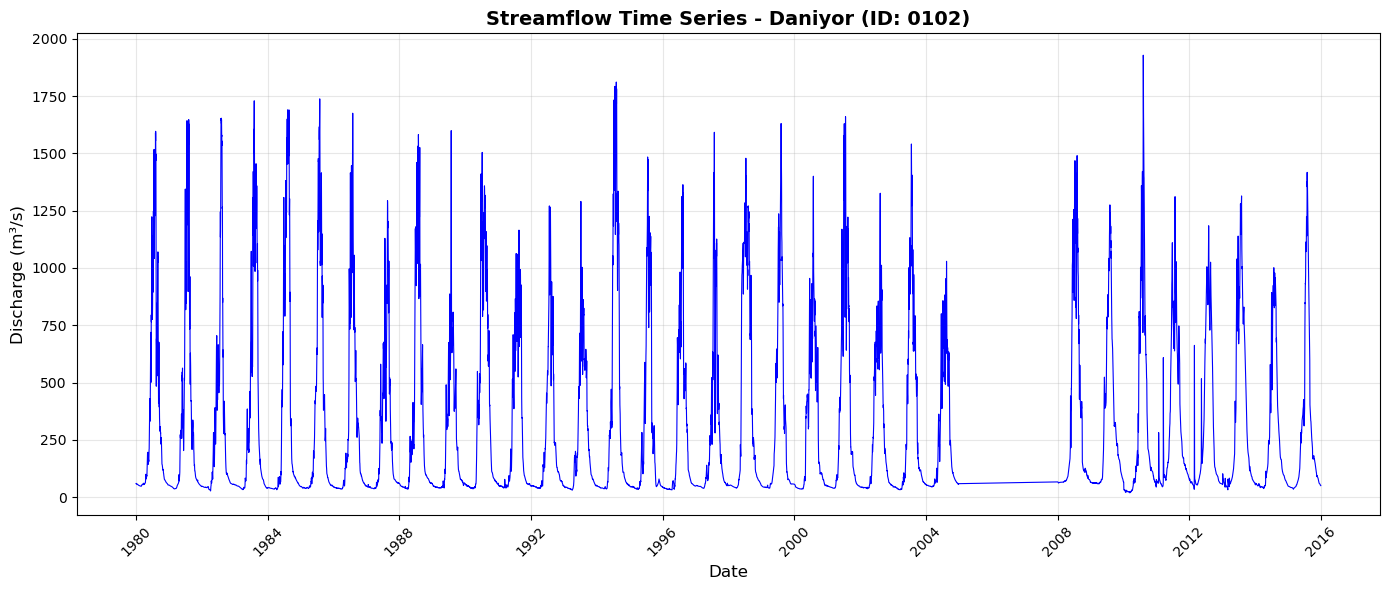

   📊 Plot saved: /home/jberg/OneDrive/Data_collection_Himalaya/streamflow/Pakistan/processed_jakob/streamflow_0102_plot.png

Processing sheet: Tarbela
   ⚠️ Using dayfirst=True for date parsing (D/M/YYYY format)
Shape: (14694, 2)
Columns: ['Date', 'Q [m3/s]']
First few rows:
                  Date Q [m3/s]
0  1980-01-01 00:00:00   493.14
1  1980-02-01 00:00:00   493.99
2  1980-03-01 00:00:00   494.84
3  1980-04-01 00:00:00   495.69
4  1980-05-01 00:00:00   496.54
   Mapped 'Tarbela' to ID: 0128
   ⚠️ Removed 8898 rows with unparseable dates
   📅 Sanity check (1980) - days per month with data: {1: np.int64(12), 2: np.int64(12), 3: np.int64(12), 4: np.int64(12), 5: np.int64(12), 6: np.int64(12), 7: np.int64(12), 8: np.int64(12), 9: np.int64(12), 10: np.int64(12), 11: np.int64(12), 12: np.int64(12)}
✅ Saved: /home/jberg/OneDrive/Data_collection_Himalaya/streamflow/Pakistan/processed_jakob/streamflow_0128.csv
   Date range: 1980-01-01 00:00:00 to 2020-03-12 00:00:00
   Total records: 14682

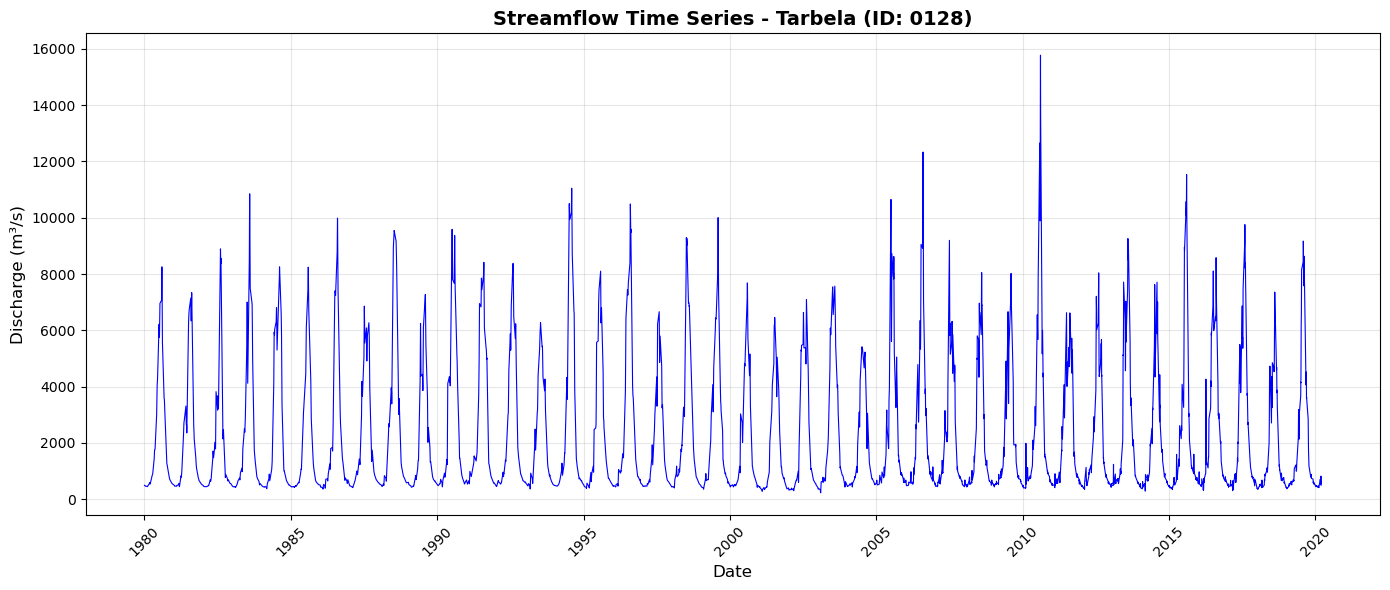

   📊 Plot saved: /home/jberg/OneDrive/Data_collection_Himalaya/streamflow/Pakistan/processed_jakob/streamflow_0128_plot.png

Processing sheet: Nowshera
Shape: (14694, 2)
Columns: ['Date', 'Q [m3/s]']
First few rows:
        Date  Q [m3/s]
0 1980-01-01    316.37
1 1980-01-02    326.14
2 1980-01-03    335.91
3 1980-01-04    345.68
4 1980-01-05    355.45
   Mapped 'Nowshera' to ID: 0129
   📅 Sanity check (1980) - days per month with data: {1: np.int64(31), 2: np.int64(29), 3: np.int64(31), 4: np.int64(30), 5: np.int64(31), 6: np.int64(30), 7: np.int64(31), 8: np.int64(31), 9: np.int64(30), 10: np.int64(31), 11: np.int64(30), 12: np.int64(31)}
✅ Saved: /home/jberg/OneDrive/Data_collection_Himalaya/streamflow/Pakistan/processed_jakob/streamflow_0129.csv
   Date range: 1980-01-01 00:00:00 to 2020-03-24 00:00:00
   Total records: 14694
   Valid data: 14691
   Missing data: 3
Shape: (14694, 2)
Columns: ['Date', 'Q [m3/s]']
First few rows:
        Date  Q [m3/s]
0 1980-01-01    316.37
1 1980-01

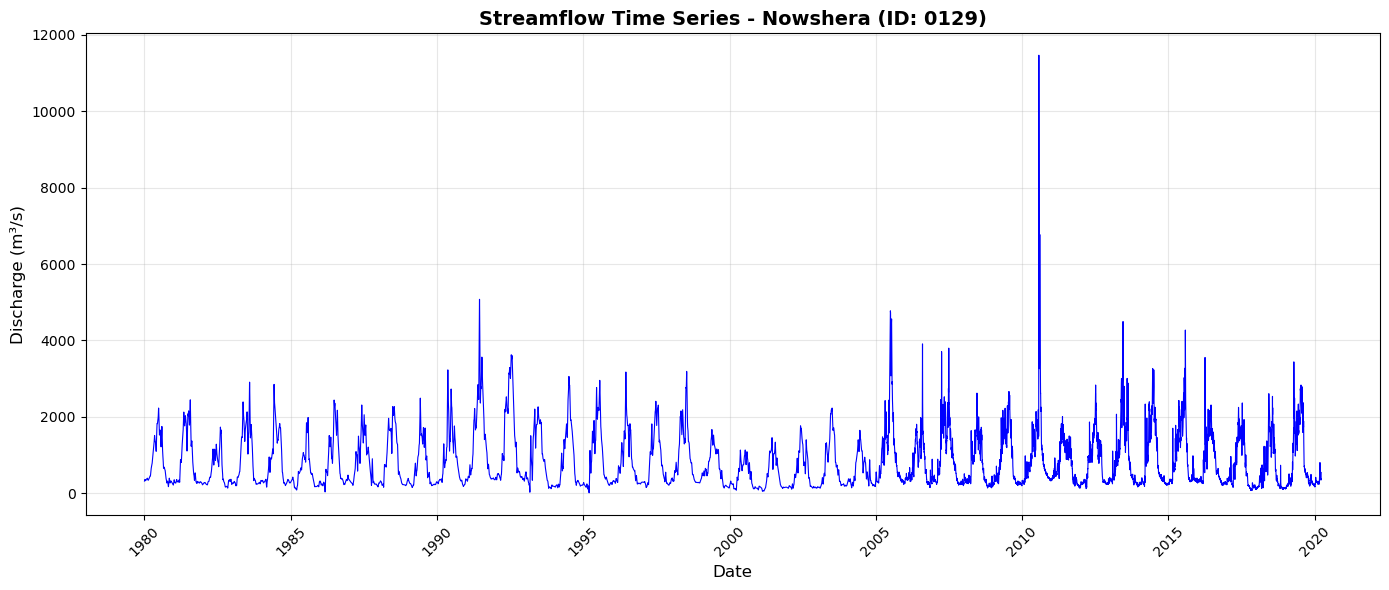

   📊 Plot saved: /home/jberg/OneDrive/Data_collection_Himalaya/streamflow/Pakistan/processed_jakob/streamflow_0129_plot.png

Processing sheet: Marala
Shape: (14694, 2)
Columns: ['Date', 'Q [m3/s]']
First few rows:
        Date  Q [m3/s]
0 1980-01-01    239.56
1 1980-01-02    254.29
2 1980-01-03    269.01
3 1980-01-04    283.73
4 1980-01-05    298.46
   Mapped 'Marala' to ID: 0130
   📅 Sanity check (1980) - days per month with data: {1: np.int64(31), 2: np.int64(29), 3: np.int64(31), 4: np.int64(30), 5: np.int64(31), 6: np.int64(30), 7: np.int64(31), 8: np.int64(31), 9: np.int64(30), 10: np.int64(31), 11: np.int64(30), 12: np.int64(31)}
✅ Saved: /home/jberg/OneDrive/Data_collection_Himalaya/streamflow/Pakistan/processed_jakob/streamflow_0130.csv
   Date range: 1980-01-01 00:00:00 to 2020-03-24 00:00:00
   Total records: 14694
   Valid data: 14691
   Missing data: 3
Shape: (14694, 2)
Columns: ['Date', 'Q [m3/s]']
First few rows:
        Date  Q [m3/s]
0 1980-01-01    239.56
1 1980-01-02 

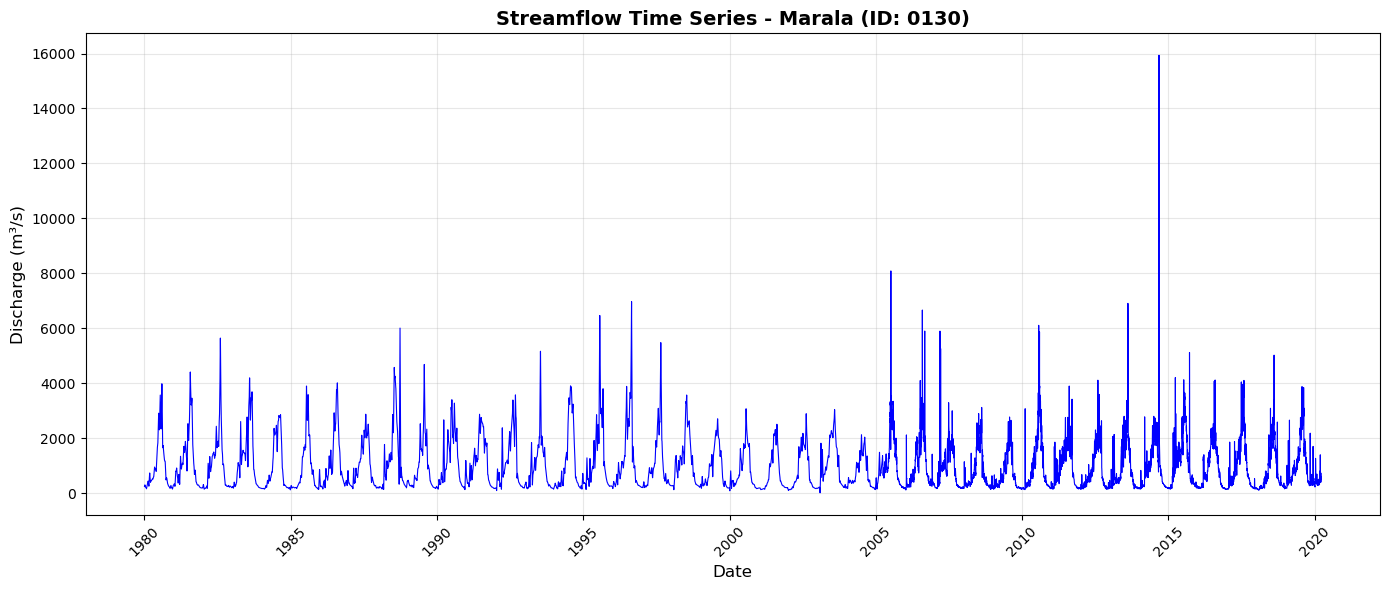

   📊 Plot saved: /home/jberg/OneDrive/Data_collection_Himalaya/streamflow/Pakistan/processed_jakob/streamflow_0130_plot.png

Processing sheet: Mangla
Shape: (14694, 2)
Columns: ['Date', 'Q [m3/s]']
First few rows:
        Date  Q [m3/s]
0 1980-01-01    250.82
1 1980-01-02    279.56
2 1980-01-03    308.30
3 1980-01-04    337.04
4 1980-01-05    365.78
   Mapped 'Mangla' to ID: 0112
   📅 Sanity check (1980) - days per month with data: {1: np.int64(31), 2: np.int64(29), 3: np.int64(31), 4: np.int64(30), 5: np.int64(31), 6: np.int64(30), 7: np.int64(31), 8: np.int64(31), 9: np.int64(30), 10: np.int64(31), 11: np.int64(30), 12: np.int64(31)}
✅ Saved: /home/jberg/OneDrive/Data_collection_Himalaya/streamflow/Pakistan/processed_jakob/streamflow_0112.csv
   Date range: 1980-01-01 00:00:00 to 2020-03-24 00:00:00
   Total records: 14694
   Valid data: 14691
   Missing data: 3
Shape: (14694, 2)
Columns: ['Date', 'Q [m3/s]']
First few rows:
        Date  Q [m3/s]
0 1980-01-01    250.82
1 1980-01-02 

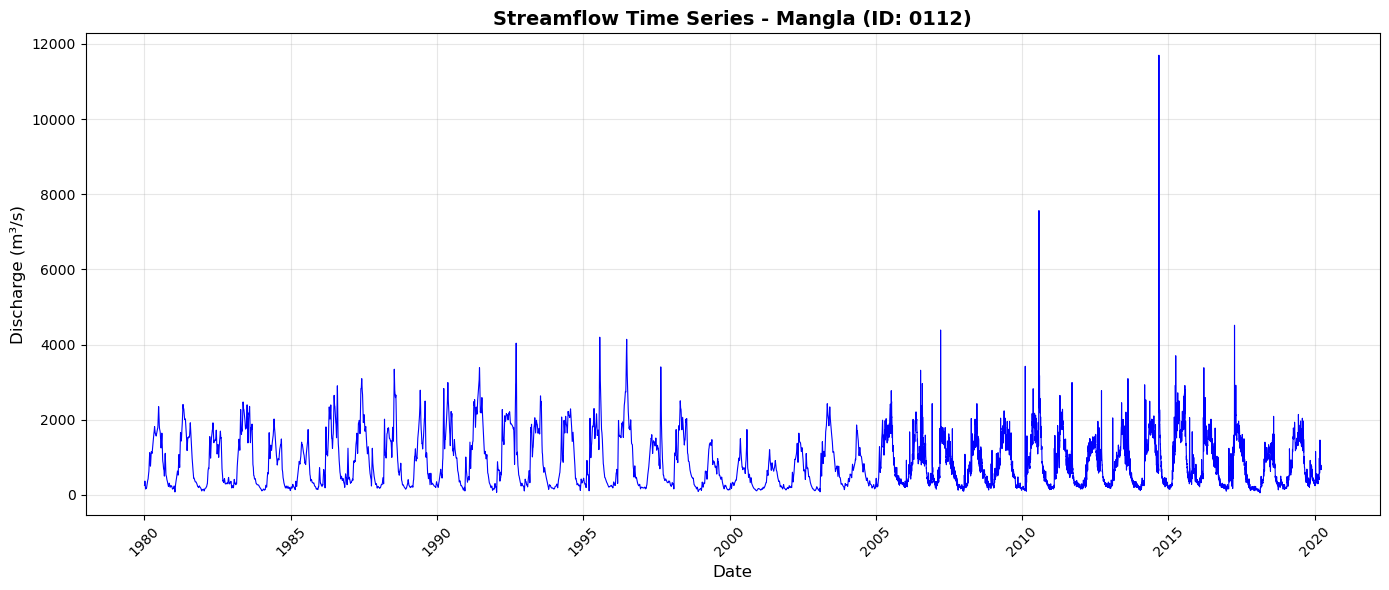

   📊 Plot saved: /home/jberg/OneDrive/Data_collection_Himalaya/streamflow/Pakistan/processed_jakob/streamflow_0112_plot.png

Processing complete!
Successfully processed: 5 sheets
Failed: 0 sheets
Total stations processed: 5


In [12]:
# Define file paths
excel_file = '/home/jberg/OneDrive/Data_collection_Himalaya/streamflow/Pakistan/IndusDataforJustine.xlsx'
output_folder = '/home/jberg/OneDrive/Data_collection_Himalaya/streamflow/Pakistan/processed_jakob'

# Process the Excel file
results = process_jakob_streamflow(excel_file, output_folder, plot=True)

## Summary Statistics

Display summary information for each processed station.

In [4]:
# Display summary statistics for each station
print("\n" + "="*80)
print("SUMMARY STATISTICS FOR ALL STATIONS")
print("="*80)

for gauge_id, df in results.items():
    print(f"\n{'='*60}")
    print(f"Station ID: {gauge_id}")
    print(f"{'='*60}")
    
    # Date range
    print(f"Date range: {df['date'].min()} to {df['date'].max()}")
    print(f"Total days: {len(df)}")
    
    # Data availability
    valid_data = df['Q_obs'].notna().sum()
    missing_data = df['Q_obs'].isna().sum()
    data_coverage = (valid_data / len(df)) * 100
    
    print(f"\nData Coverage:")
    print(f"  Valid records: {valid_data} ({data_coverage:.1f}%)")
    print(f"  Missing records: {missing_data} ({100-data_coverage:.1f}%)")
    
    # Discharge statistics (only for valid data)
    if valid_data > 0:
        print(f"\nDischarge Statistics (m³/s):")
        print(f"  Mean: {df['Q_obs'].mean():.2f}")
        print(f"  Median: {df['Q_obs'].median():.2f}")
        print(f"  Std Dev: {df['Q_obs'].std():.2f}")
        print(f"  Min: {df['Q_obs'].min():.2f}")
        print(f"  Max: {df['Q_obs'].max():.2f}")
        print(f"  25th percentile: {df['Q_obs'].quantile(0.25):.2f}")
        print(f"  75th percentile: {df['Q_obs'].quantile(0.75):.2f}")
    else:
        print(f"\n  ⚠️ No valid discharge data available")


SUMMARY STATISTICS FOR ALL STATIONS

Station ID: 0102
Date range: 1980-01-01 00:00:00 to 2016-12-31 00:00:00
Total days: 13515

Data Coverage:
  Valid records: 12054 (89.2%)
  Missing records: 1461 (10.8%)

Discharge Statistics (m³/s):
  Mean: 302.12
  Median: 95.31
  Std Dev: 378.45
  Min: 18.86
  Max: 1928.00
  25th percentile: 50.92
  75th percentile: 434.68

Station ID: 0128
Date range: 1980-01-01 00:00:00 to 2020-12-03 00:00:00
Total days: 14948

Data Coverage:
  Valid records: 14691 (98.3%)
  Missing records: 257 (1.7%)

Discharge Statistics (m³/s):
  Mean: 2333.81
  Median: 1022.24
  Std Dev: 2436.19
  Min: 227.81
  Max: 20107.76
  25th percentile: 595.09
  75th percentile: 3574.32

Station ID: 0129
Date range: 1980-01-01 00:00:00 to 2020-03-24 00:00:00
Total days: 14694

Data Coverage:
  Valid records: 14691 (100.0%)
  Missing records: 3 (0.0%)

Discharge Statistics (m³/s):
  Mean: 821.95
  Median: 519.47
  Std Dev: 721.22
  Min: 7.94
  Max: 11468.30
  25th percentile: 283.19


## Check Output Files

Verify that all CSV files were created successfully.

In [5]:
# List all output files created
import glob

print(f"\nOutput folder: {output_folder}")
print(f"\n{'='*60}")
print("Files created:")
print(f"{'='*60}")

csv_files = sorted(glob.glob(os.path.join(output_folder, "streamflow_*.csv")))
plot_files = sorted(glob.glob(os.path.join(output_folder, "streamflow_*.png")))

print(f"\nCSV files ({len(csv_files)}):")
for f in csv_files:
    file_size = os.path.getsize(f) / 1024  # Size in KB
    print(f"  ✓ {os.path.basename(f)} ({file_size:.1f} KB)")

print(f"\nPlot files ({len(plot_files)}):")
for f in plot_files:
    file_size = os.path.getsize(f) / 1024  # Size in KB
    print(f"  ✓ {os.path.basename(f)} ({file_size:.1f} KB)")

print(f"\n{'='*60}")
print(f"Total files created: {len(csv_files) + len(plot_files)}")


Output folder: /home/jberg/OneDrive/Data_collection_Himalaya/streamflow/Pakistan/processed_jakob

Files created:

CSV files (5):
  ✓ streamflow_0102.csv (223.0 KB)
  ✓ streamflow_0112.csv (296.9 KB)
  ✓ streamflow_0128.csv (287.1 KB)
  ✓ streamflow_0129.csv (278.8 KB)
  ✓ streamflow_0130.csv (296.8 KB)

Plot files (5):
  ✓ streamflow_0102_plot.png (412.9 KB)
  ✓ streamflow_0112_plot.png (293.4 KB)
  ✓ streamflow_0128_plot.png (447.6 KB)
  ✓ streamflow_0129_plot.png (297.7 KB)
  ✓ streamflow_0130_plot.png (299.2 KB)

Total files created: 10


## Investigate Tarbela Data - Plot Individual Years

Let's plot a few individual years for Tarbela (ID: 0128) to see what's happening with the data.

Tarbela data available from 1980 to 2020
Total years: 41

Plotting years: [np.int32(1980), np.int32(1985), np.int32(2000), np.int32(2011), np.int32(2020)]


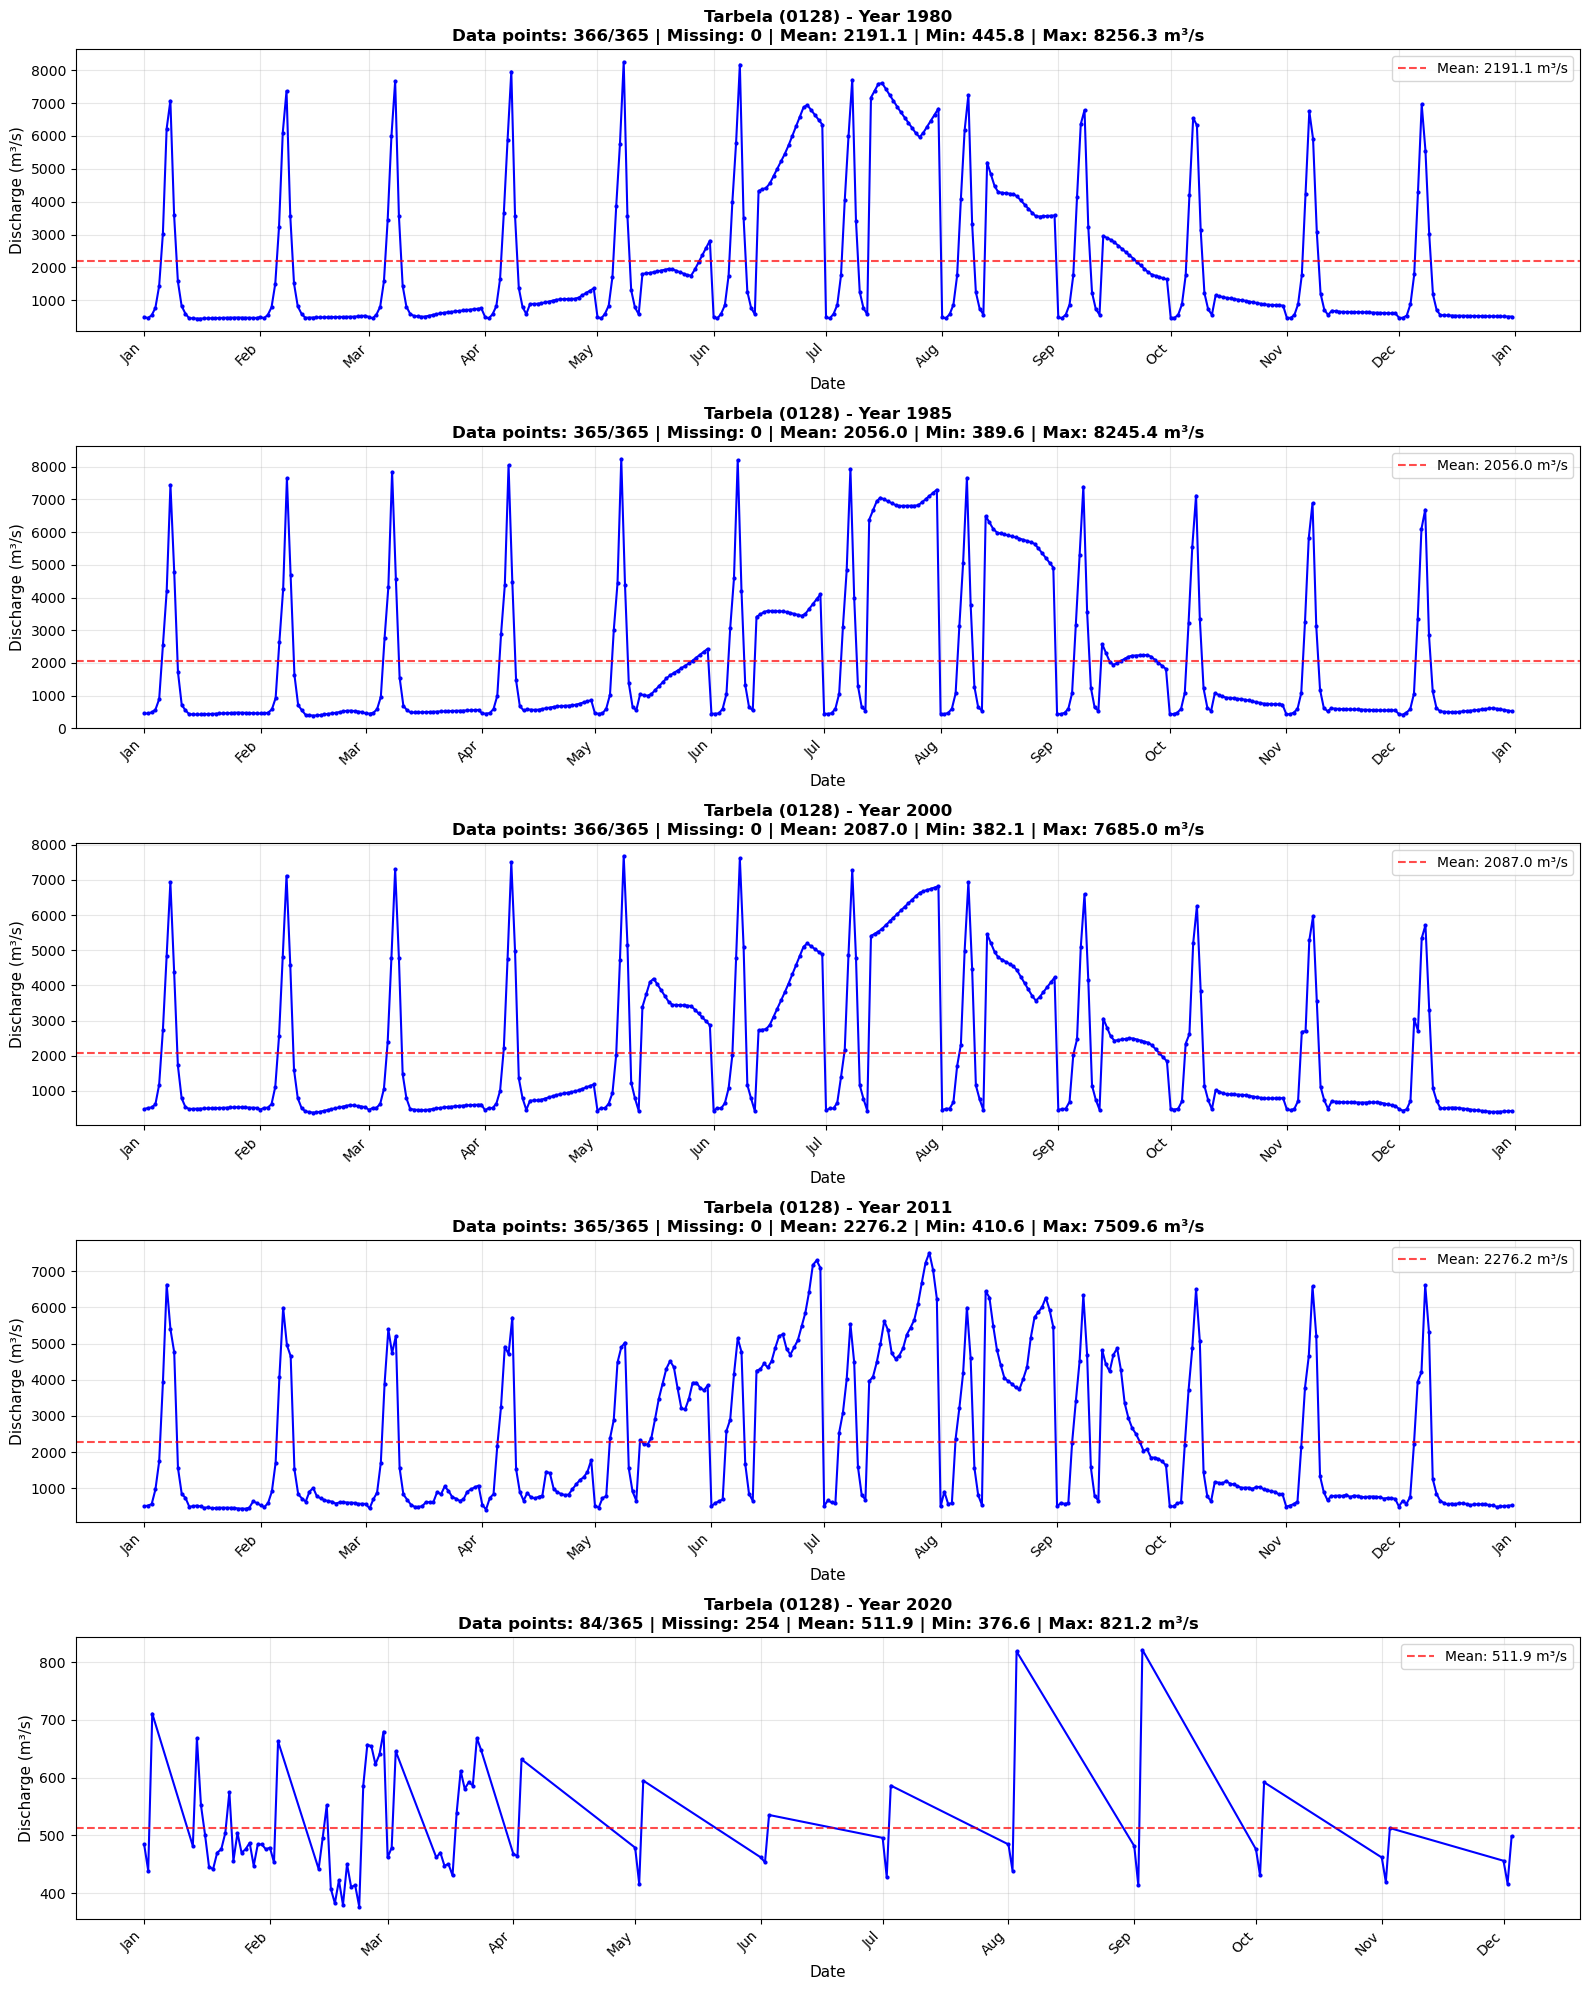


Observation: Check for any unusual patterns, gaps, or anomalies


In [6]:
# Get Tarbela data
tarbela_id = '0128'
df_tarbela = results[tarbela_id].copy()

# Add year column for filtering
df_tarbela['year'] = df_tarbela['date'].dt.year

# Get available years
available_years = sorted(df_tarbela['year'].unique())
print(f"Tarbela data available from {available_years[0]} to {available_years[-1]}")
print(f"Total years: {len(available_years)}")

# Select a few years to plot (beginning, middle, end, and some random ones)
years_to_plot = [
    available_years[0],      # First year
    available_years[5],      # Early year
    available_years[len(available_years)//2],  # Middle year
    available_years[-10],    # Recent year
    available_years[-1]      # Last year
]

print(f"\nPlotting years: {years_to_plot}")

# Create subplots for each year
fig, axes = plt.subplots(len(years_to_plot), 1, figsize=(16, 4*len(years_to_plot)))

for i, year in enumerate(years_to_plot):
    ax = axes[i] if len(years_to_plot) > 1 else axes
    
    # Filter data for this year
    df_year = df_tarbela[df_tarbela['year'] == year].copy()
    
    # Plot only non-NaN values
    df_plot = df_year.dropna(subset=['Q_obs'])
    
    if len(df_plot) > 0:
        ax.plot(df_plot['date'], df_plot['Q_obs'], 'b-', linewidth=1.5, marker='o', markersize=2)
        
        # Add statistics
        mean_val = df_plot['Q_obs'].mean()
        max_val = df_plot['Q_obs'].max()
        min_val = df_plot['Q_obs'].min()
        data_points = len(df_plot)
        missing_points = len(df_year) - data_points
        
        ax.axhline(y=mean_val, color='r', linestyle='--', alpha=0.7, label=f'Mean: {mean_val:.1f} m³/s')
        
        ax.set_title(f'Tarbela (0128) - Year {year}\n'
                    f'Data points: {data_points}/365 | Missing: {missing_points} | '
                    f'Mean: {mean_val:.1f} | Min: {min_val:.1f} | Max: {max_val:.1f} m³/s', 
                    fontsize=12, fontweight='bold')
        ax.set_ylabel('Discharge (m³/s)', fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right', fontsize=10)
    else:
        ax.text(0.5, 0.5, f'No data available for {year}', 
               transform=ax.transAxes, ha='center', va='center', fontsize=14)
        ax.set_title(f'Tarbela (0128) - Year {year}', fontsize=12, fontweight='bold')
    
    # Format x-axis
    ax.set_xlabel('Date', fontsize=11)
    import matplotlib.dates as mdates
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("Observation: Check for any unusual patterns, gaps, or anomalies")